In [1]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info
from config import draft_mllm_name, prompt, target_mllm_name
import torch
import cv2
img = cv2.imread('./imgs/book.jpg')

h, w = img.shape[:2]

model_name = target_mllm_name

draft_mllm = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_name,
    dtype=torch.bfloat16,
    # attn_implementation="flash_attention_2",
    device_map="auto",
)

min_pixels = 256*28*28
max_pixels = 1280*28*28
processor = AutoProcessor.from_pretrained(model_name, min_pixels=min_pixels, max_pixels=max_pixels)

tokenizer = processor.tokenizer

prompt = f'''
Identify the open book in the image(height, width= {h, w}) and generate a set of coordinate points that form a closed polygon enclosing the book.

Requirements:
- The polygon must tightly enclose the visible area of the open book.
- Use as few points as possible while still accurately enclosing the shape.
- The number of points must be 4.
- Each of the 4 points must be unique; do not repeat the same coordinate.
- Avoid unnecessary points; do not add redundant vertices along straight edges.
- Points must be ordered in clockwise order.

- Use normalized coordinates:
  - Each point is in the format [x, y]
  - x is the horizontal coordinate (left → right)
  - y is the vertical coordinate (top → bottom)
  - (0, 0) is the top-left corner of the image
  - (1, 1) is the bottom-right corner of the image
  - All values must be floats in the range [0, 1]

- Do NOT use pixel coordinates
- Do NOT output integers

Output format (strictly follow this JSON format, no extra text):
{{
  "points": [[x1, y1], [x2, y2], [x3, y3], [x4, y4]]
}}
'''

prompt = '''
请检测图像中一本打开的书。请以归一化坐标（0-1000范围）的标准格式输出该框的左上角点和右下角点坐标，格式为`[ymin, xmin, ymax, xmax]`。输出应为一个包含此信息的JSON列表。

预期的JSON格式：
```json
[
  {
    "box_2d": [ymin, xmin, ymax, xmax],
    "label": "黑色矩形框"
  }
]
'''

_prompt = f'''
Image: Stack of books against a blue background, with the single top book fully open (red cover, white pages).
Task: Accurately identify the **top open book** only and provide its bounding box.
Image Dimensions: height={h}, width={w}.

Instructions:
1. First, in one brief sentence, describe the position of the red open book relative to other items and the image boundaries. For example, "The open book is on top of the stack, with its top edge near the top of the image and its right edge towards the right."
2. Then, output the single bounding box that tightly encloses this open book, including its cover and open pages.
3. Use standardized integer coordinates in the range of [0, 1000].
4. Coordinate format: [xmin, ymin, xmax, ymax] where:
   - xmin: left edge coordinate
   - ymin: top edge coordinate
   - xmax: right edge coordinate
   - ymax: bottom edge coordinate
5. (0, 0) is the top-left corner, and (1000, 1000) is the bottom-right.
6. Provide only the text description first, then the coordinates.

Output format (strictly follow this JSON format):
{{
  "thought": "your single-sentence description",
  "bounding_box": [xmin, ymin, xmax, ymax]
}}
'''

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                # "image": "https://qianwen-res.oss-cn-beijing.aliyuncs.com/Qwen-VL/assets/demo.jpeg",
                # "image": "https://img95.699pic.com/photo/50261/8377.jpg_wh860.jpg",
                "image": "./imgs/book.jpg",
            },
            {"type": "text", "text": prompt},
        ],
    }
]

# Preparation for inference
text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
).to("cuda")

generated_ids = draft_mllm.generate(**inputs, max_new_tokens=256)
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.


In [2]:
import json
import re

def extract_json(text):
    # 去掉 ```json ``` 包裹
    text = text.strip()

    # 匹配 ```json ... ```
    match = re.search(r"```(?:json)?\s*(\{.*?\})\s*```", text, re.DOTALL)
    if match:
        text = match.group(1)

    # 再尝试直接找 JSON
    else:
        match = re.search(r"\{.*\}", text, re.DOTALL)
        if match:
            text = match.group(0)

    return json.loads(text)

In [3]:
output_text[0]

'```json\n[\n  {\n    "box_2d": [196, 20, 705, 280],\n    "label": "一本打开的书"\n  }\n]\n```'

In [4]:
points_json = extract_json(output_text[0])
points_json

{'box_2d': [196, 20, 705, 278], 'label': '一本打开的书'}

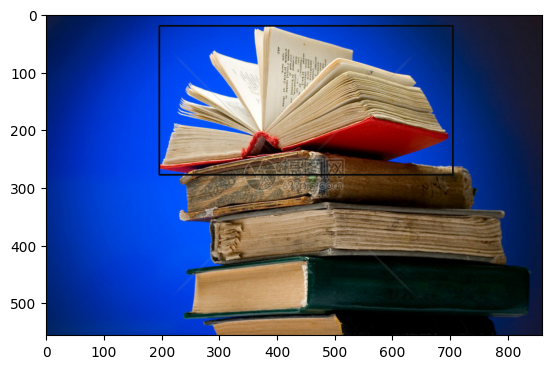

In [17]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('./imgs/book.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w = img.shape[:2]

ymin, xmin, ymax, xmax = points_json['box_2d']
# cv2.circle(img, (ymin, xmin), 3, (255, 0, 0), -1)
# cv2.circle(img, (ymax, xmax), 3, (255, 0, 0), -1)
cv2.rectangle(img, (ymin, xmin), (ymax, xmax), (10, 10, 10), 2)
plt.imshow(img)
plt.show()

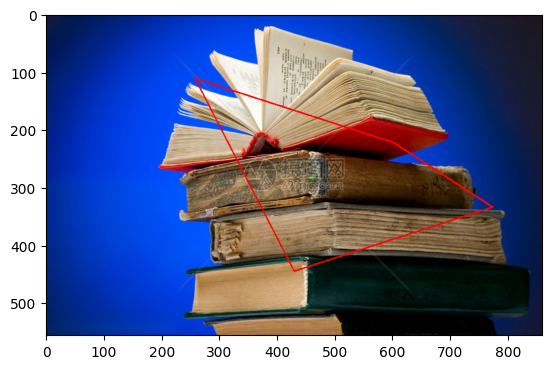

In [5]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('./imgs/book.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w = img.shape[:2]

# for x, y in points_json['points']:
#     px = int(round(x * w))
#     py = int(round(y * h))
#     cv2.circle(img, (px, py), 3, (255, 0, 0), -1)
# plt.imshow(img)
# plt.show()
import numpy as np

pts = []
for x, y in points_json['points']:
    px = int(round(x * w))
    py = int(round(y * h))
    pts.append([px, py])

pts = np.array(pts, np.int32)
pts = pts.reshape((-1, 1, 2))

cv2.polylines(img, [pts], isClosed=True, color=(255, 0, 0), thickness=2)

plt.imshow(img)
plt.show()